#### Setup y Preparación

In [2]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from config import BRONZE_DIR
import matplotlib.dates as mdates

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

PARQUET_PATH = BRONZE_DIR / "rips_limpio.parquet"
con = duckdb.connect()

#### Serie Temporal Global: Atenciones Totales por Año

     Año  total_atenciones  n_registros
0   2009       103647922.0      1183667
1   2010       117239999.0      1274885
2   2011       147047328.0      1487434
3   2012       177694743.0      1616654
4   2013       145608545.0      1680044
5   2014       208540898.0      2009467
6   2015       194904245.0      1900852
7   2016       133987627.0      1723057
8   2017       211215369.0      2013316
9   2018       301590731.0      2245360
10  2019       309991292.0      2952548
11  2020       244751976.0      2529062
12  2021       233708510.0      2384496


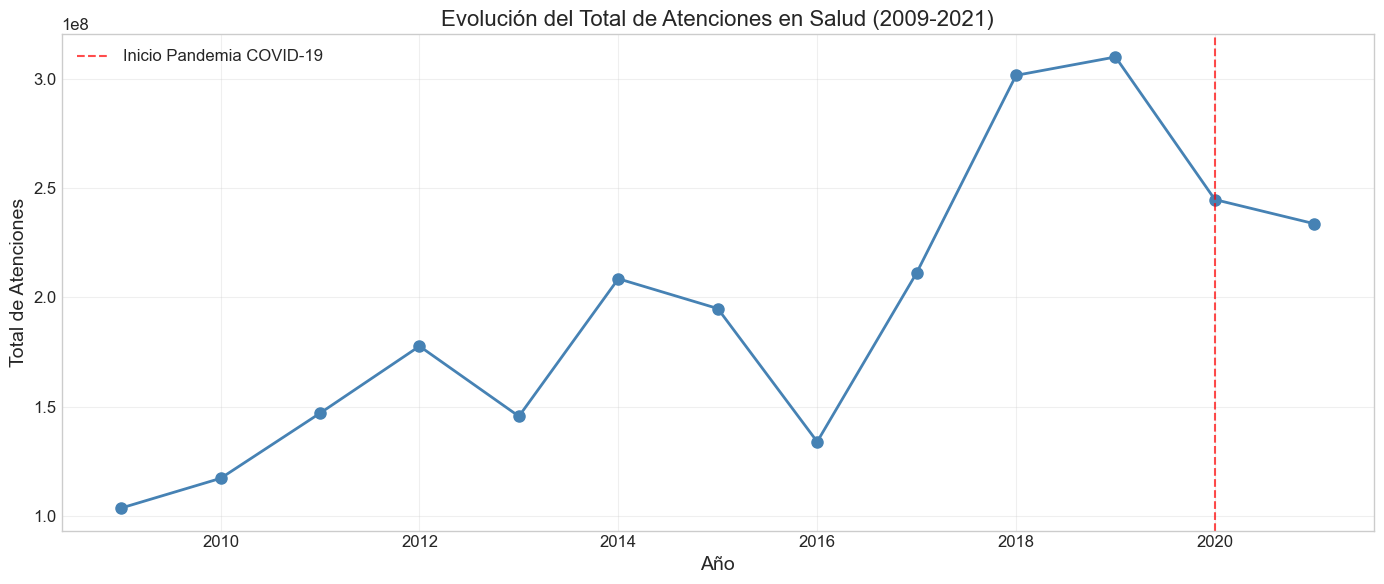

In [3]:
# Agregar por año
atenciones_anio = con.execute(f"""
    SELECT 
        Año,
        SUM(NumeroAtenciones) as total_atenciones,
        COUNT(*) as n_registros
    FROM '{PARQUET_PATH}'
    GROUP BY Año
    ORDER BY Año
""").fetchdf()

print(atenciones_anio)

# Gráfico de evolución
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(atenciones_anio['Año'], atenciones_anio['total_atenciones'], marker='o', linewidth=2, markersize=8, color='steelblue')
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Evolución del Total de Atenciones en Salud (2009-2021)', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Total de Atenciones', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_evolucion_atenciones.png', dpi=150, bbox_inches='tight')
plt.show()

#### Serie Temporal por Tipo de Atención

    Año             TipoAtencion  total_atenciones
0  2009                CONSULTAS        45458930.0
1  2009        HOSPITALIZACIONES          743772.0
2  2009  PROCEDIMIENTOS DE SALUD        55847224.0
3  2009                URGENCIAS         1597996.0
4  2010                CONSULTAS        44660894.0


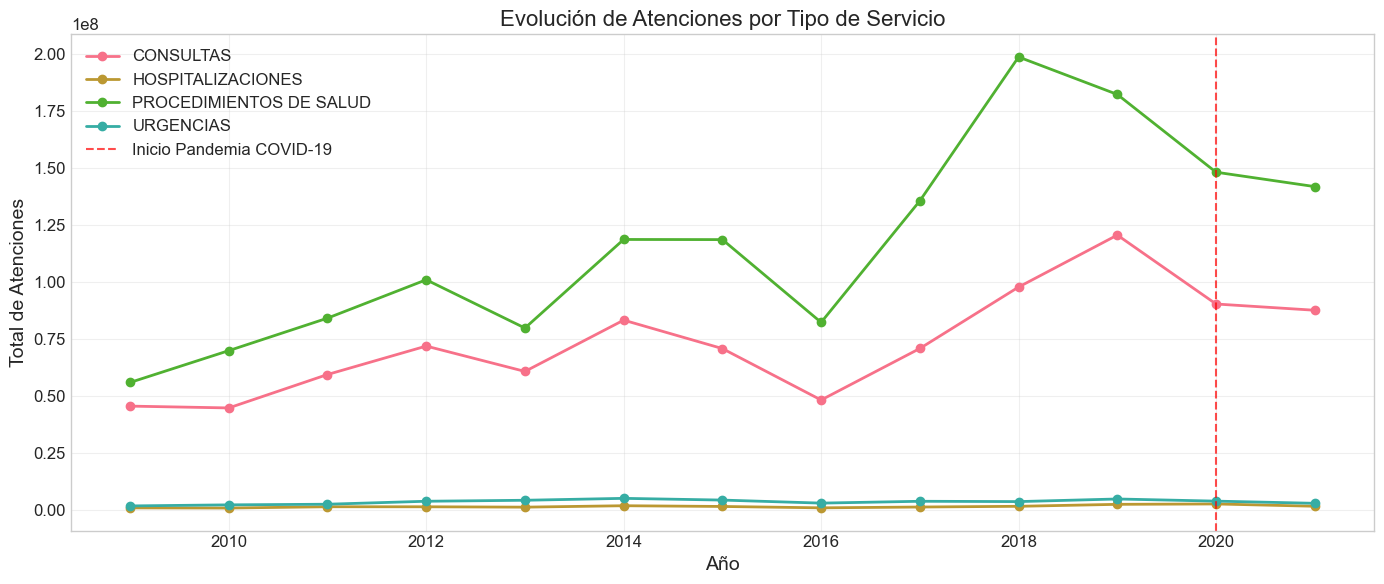

In [4]:
# Agregar por año y tipo
atenciones_anio_tipo = con.execute(f"""
    SELECT 
        Año,
        TipoAtencion,
        SUM(NumeroAtenciones) as total_atenciones
    FROM '{PARQUET_PATH}'
    GROUP BY Año, TipoAtencion
    ORDER BY Año, TipoAtencion
""").fetchdf()

print(atenciones_anio_tipo.head())

# Pivot para gráfico
pivot_tipo = atenciones_anio_tipo.pivot(index='Año', columns='TipoAtencion', values='total_atenciones')

# Gráfico de líneas por tipo
fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_tipo.columns:
    ax.plot(pivot_tipo.index, pivot_tipo[col], marker='o', label=col, linewidth=2)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Evolución de Atenciones por Tipo de Servicio', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Total de Atenciones', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_evolucion_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

#### Análisis del Outlier de Bogotá: Impacto en la Serie Temporal

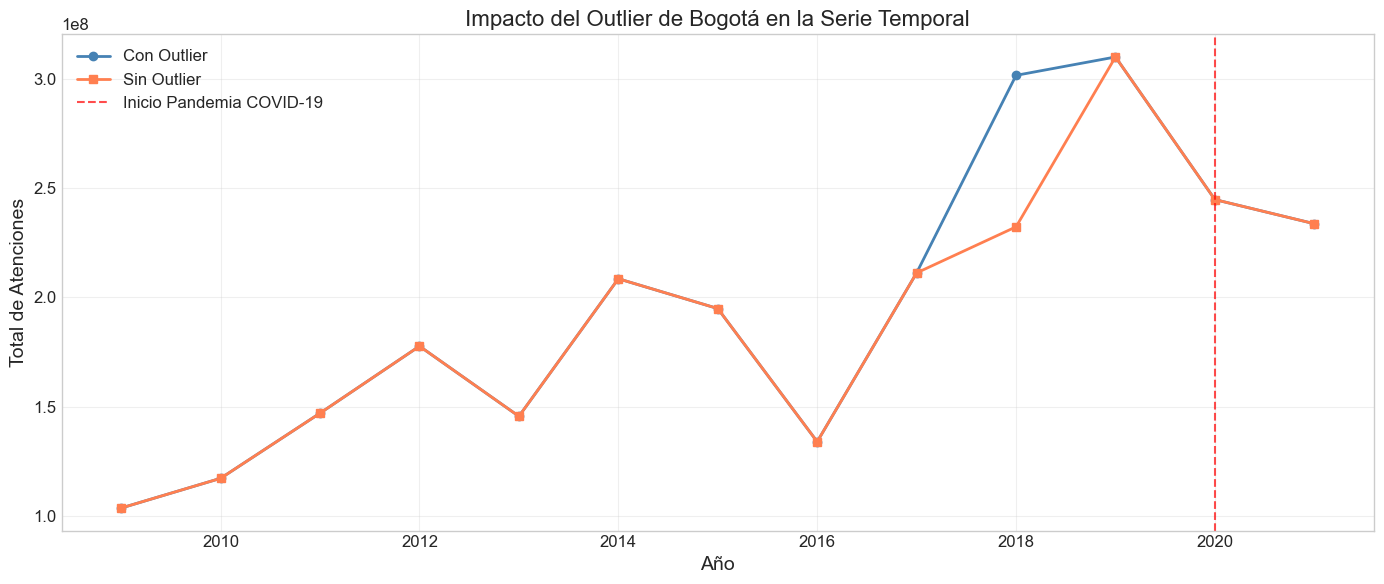

In [5]:
# Calcular el total sin el outlier de Bogotá (2018, PROCEDIMIENTOS, NO DEFINIDO)
atenciones_anio_sin_outlier = con.execute(f"""
    SELECT 
        Año,
        SUM(NumeroAtenciones) as total_atenciones
    FROM '{PARQUET_PATH}'
    WHERE NOT (Año = 2018 AND es_no_definido AND TipoAtencion = 'PROCEDIMIENTOS DE SALUD')
    GROUP BY Año
    ORDER BY Año
""").fetchdf()

# Comparar ambas series
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(atenciones_anio['Año'], atenciones_anio['total_atenciones'], 
        marker='o', label='Con Outlier', color='steelblue', linewidth=2)
ax.plot(atenciones_anio_sin_outlier['Año'], atenciones_anio_sin_outlier['total_atenciones'], 
        marker='s', label='Sin Outlier', color='coral', linewidth=2)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Impacto del Outlier de Bogotá en la Serie Temporal', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Total de Atenciones', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_impacto_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

#### Análisis de la Pandemia: Cambio de Tendencia

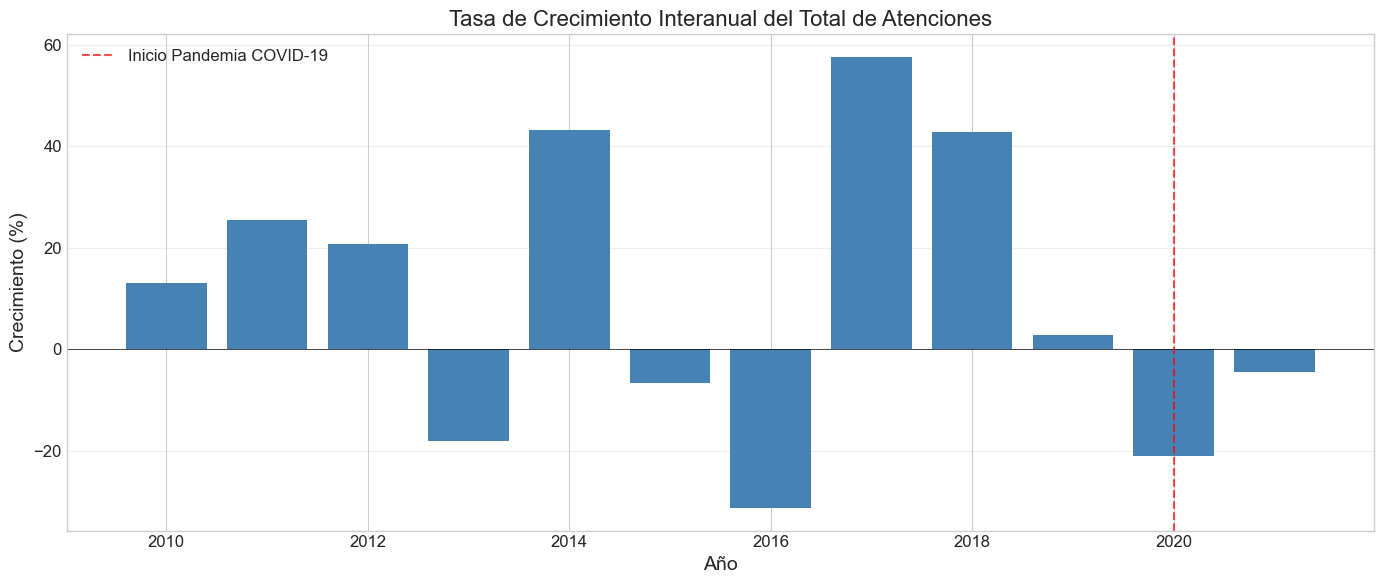

In [6]:
# Calcular crecimiento interanual
atenciones_anio['crecimiento_anual'] = atenciones_anio['total_atenciones'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(atenciones_anio['Año'][1:], atenciones_anio['crecimiento_anual'][1:], color='steelblue')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Tasa de Crecimiento Interanual del Total de Atenciones', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Crecimiento (%)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../reports/figures/04_crecimiento_anual.png', dpi=150, bbox_inches='tight')
plt.show()

#### Análisis del "NO DEFINIDO" en el Tiempo

     Año  atenciones_no_def  total_atenciones  pct_no_def
0   2009         32286560.0       103647922.0       31.15
1   2010         36498261.0       117239999.0       31.13
2   2011         43511250.0       147047328.0       29.59
3   2012         50668690.0       177694743.0       28.51
4   2013         37147991.0       145608545.0       25.51
5   2014         60165573.0       208540898.0       28.85
6   2015         56578300.0       194904245.0       29.03
7   2016         42508731.0       133987627.0       31.73
8   2017         59371734.0       211215369.0       28.11
9   2018         69303242.0       301590731.0       22.98
10  2019         68872670.0       309991292.0       22.22
11  2020         49666741.0       244751976.0       20.29
12  2021         48268658.0       233708510.0       20.65


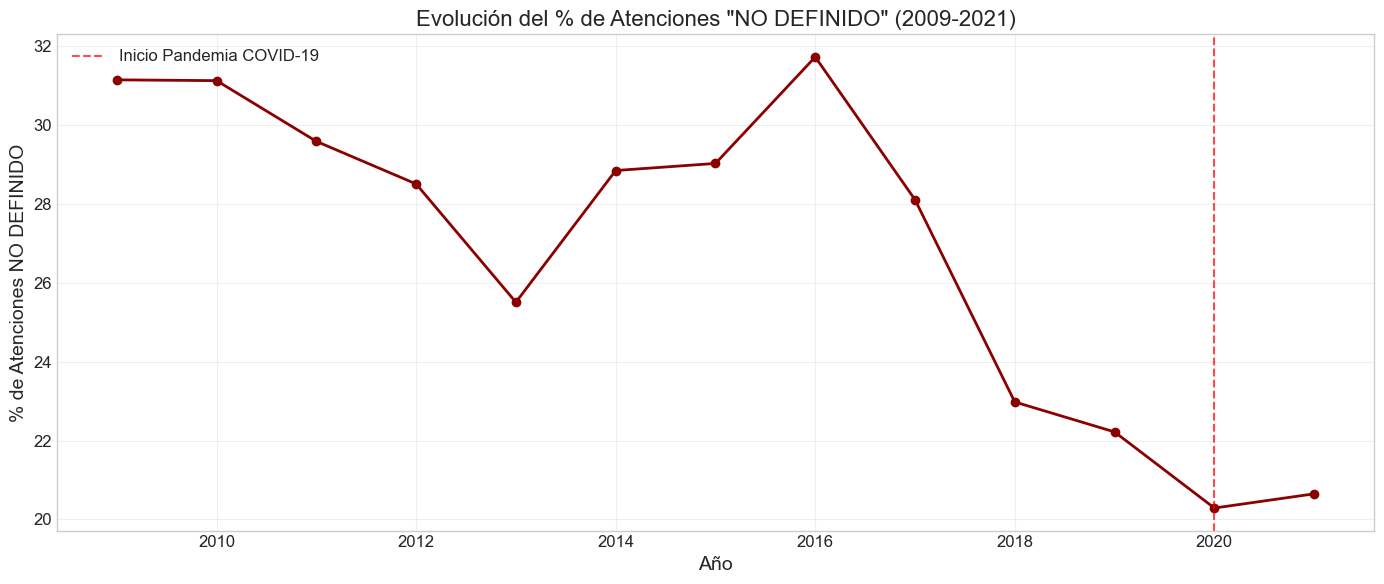

In [7]:
no_definido_anio = con.execute(f"""
    SELECT 
        Año,
        SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) as atenciones_no_def,
        SUM(NumeroAtenciones) as total_atenciones,
        ROUND((SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) * 100.0 / SUM(NumeroAtenciones)), 2) as pct_no_def
    FROM '{PARQUET_PATH}'
    GROUP BY Año
    ORDER BY Año
""").fetchdf()

print(no_definido_anio)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(no_definido_anio['Año'], no_definido_anio['pct_no_def'], marker='o', linewidth=2, color='darkred')
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Evolución del % de Atenciones "NO DEFINIDO" (2009-2021)', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('% de Atenciones NO DEFINIDO', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_evolucion_no_definido.png', dpi=150, bbox_inches='tight')
plt.show()

#### Guardar Resultados

In [8]:
# Guardar todas las tablas de agregación para usarlas en el análisis espacial
atenciones_anio.to_csv('../reports/atenciones_por_anio.csv', index=False)
atenciones_anio_tipo.to_csv('../reports/atenciones_por_anio_tipo.csv', index=False)
no_definido_anio.to_csv('../reports/no_definido_por_anio.csv', index=False)

print("✅ Análisis temporal completado. Archivos guardados en reports/")

✅ Análisis temporal completado. Archivos guardados en reports/


#### Análisis Estadístico de Tendencias

In [9]:
from scipy import stats

# Prueba de Mann-Kendall (sin paquete externo, usando kendalltau)
tau_con, p_con = stats.kendalltau(atenciones_anio['Año'], atenciones_anio['total_atenciones'])
tau_sin, p_sin = stats.kendalltau(atenciones_anio_sin_outlier['Año'], atenciones_anio_sin_outlier['total_atenciones'])

print("=== PRUEBA DE TENDENCIA (Mann-Kendall via Kendall Tau) ===")
print(f"Con outlier:  tau = {tau_con:.4f}, p-valor = {p_con:.5f}")
print(f"Sin outlier:  tau = {tau_sin:.4f}, p-valor = {p_sin:.5f}")
print()
if p_con < 0.05:
    print("→ Con outlier: tendencia MONÓTONA estadísticamente significativa (p < 0.05)")
else:
    print("→ Con outlier: NO hay tendencia monótona significativa (p >= 0.05)")

if p_sin < 0.05:
    print("→ Sin outlier: tendencia MONÓTONA estadísticamente significativa (p < 0.05)")
else:
    print("→ Sin outlier: NO hay tendencia monótona significativa (p >= 0.05)")

=== PRUEBA DE TENDENCIA (Mann-Kendall via Kendall Tau) ===
Con outlier:  tau = 0.6667, p-valor = 0.00094
Sin outlier:  tau = 0.7179, p-valor = 0.00028

→ Con outlier: tendencia MONÓTONA estadísticamente significativa (p < 0.05)
→ Sin outlier: tendencia MONÓTONA estadísticamente significativa (p < 0.05)


#### Evolución del "NO DEFINIDO" por Tipo de Atención

    Año             TipoAtencion  atenciones_no_def  total_atenciones  \
0  2009                CONSULTAS                0.0        45458930.0   
1  2009        HOSPITALIZACIONES                0.0          743772.0   
2  2009  PROCEDIMIENTOS DE SALUD         32286560.0        55847224.0   
3  2009                URGENCIAS                0.0         1597996.0   
4  2010                CONSULTAS                0.0        44660894.0   
5  2010        HOSPITALIZACIONES                0.0          674324.0   
6  2010  PROCEDIMIENTOS DE SALUD         36498261.0        69834496.0   
7  2010                URGENCIAS                0.0         2070285.0   
8  2011                CONSULTAS                0.0        59344164.0   
9  2011        HOSPITALIZACIONES                0.0         1238212.0   

   pct_no_def  
0        0.00  
1        0.00  
2       57.81  
3        0.00  
4        0.00  
5        0.00  
6       52.26  
7        0.00  
8        0.00  
9        0.00  


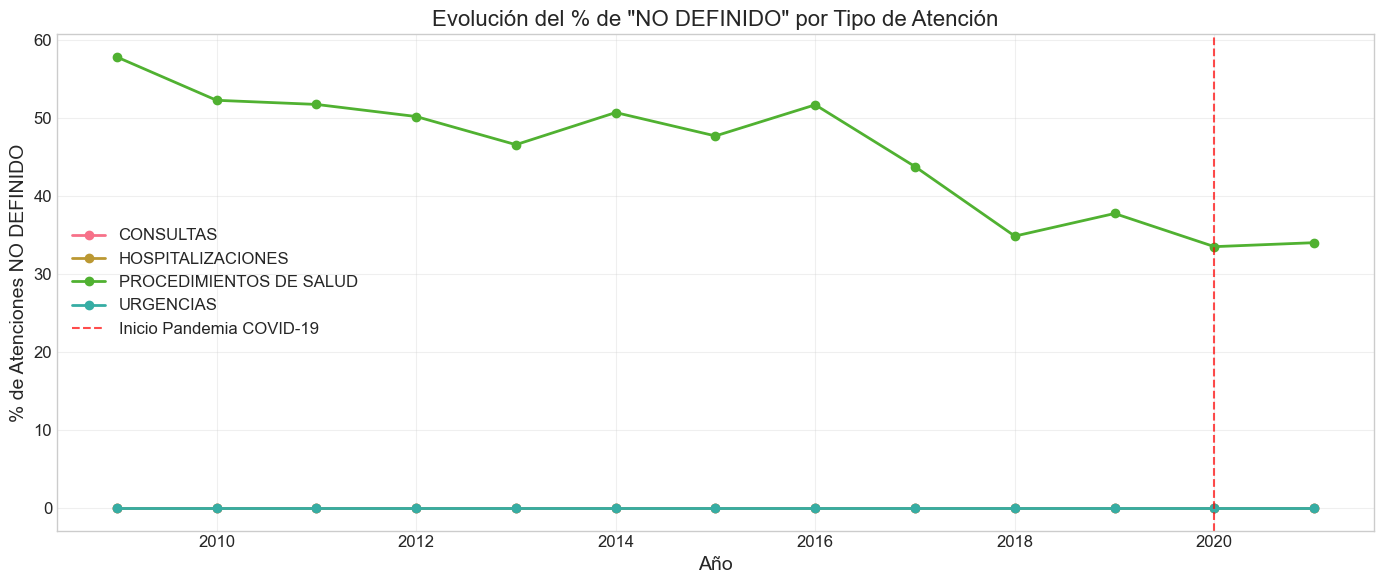

In [10]:
no_def_tipo_anio = con.execute(f"""
    SELECT 
        Año,
        TipoAtencion,
        SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) as atenciones_no_def,
        SUM(NumeroAtenciones) as total_atenciones,
        ROUND(SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) * 100.0 
              / NULLIF(SUM(NumeroAtenciones), 0), 2) as pct_no_def
    FROM '{PARQUET_PATH}'
    GROUP BY Año, TipoAtencion
    ORDER BY Año, TipoAtencion
""").fetchdf()

print(no_def_tipo_anio.head(10))

# Pivot para gráfico
pivot_no_def = no_def_tipo_anio.pivot(index='Año', columns='TipoAtencion', values='pct_no_def')

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_no_def.columns:
    ax.plot(pivot_no_def.index, pivot_no_def[col], marker='o', label=col, linewidth=2)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Evolución del % de "NO DEFINIDO" por Tipo de Atención', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('% de Atenciones NO DEFINIDO', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_no_definido_por_tipo_anio.png', dpi=150, bbox_inches='tight')
plt.show()

#### Top 5 Diagnósticos por Año (Evolución)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     Año                                        Diagnostico  total_atenciones  \
0   2009            I10X - HIPERTENSION ESENCIAL (PRIMARIA)         4224148.0   
1   2009                       Z000 - EXAMEN MEDICO GENERAL         2639328.0   
2   2009                        K021 - CARIES DE LA DENTINA         2107293.0   
3   2009         Z001 - CONTROL DE SALUD DE RUTINA DEL NIÑO         1830302.0   
4   2009  N390 - INFECCION DE VIAS URINARIAS, SITIO NO E...         1379324.0   
5   2010            I10X - HIPERTENSION ESENCIAL (PRIMARIA)         5992068.0   
6   2010                       Z000 - EXAMEN MEDICO GENERAL         3166254.0   
7   2010                       Z017 - EXAMEN DE LABORATORIO         2936252.0   
8   2010                        K021 - CARIES DE LA DENTINA         2119876.0   
9   2010         Z001 - CONTROL DE SALUD DE RUTINA DEL NIÑO         1815736.0   
10  2011            I10X - HIPERTENSION ESENCIAL (PRIMARIA)         7724125.0   
11  2011                    

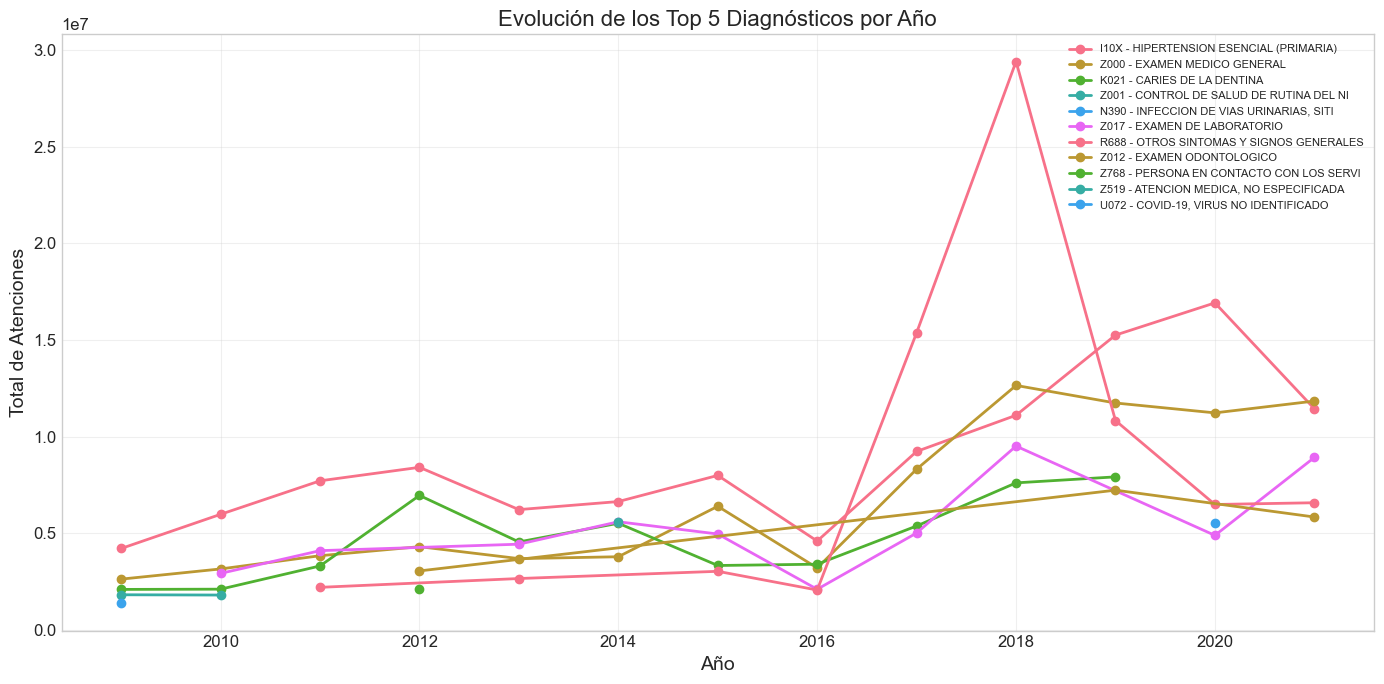

In [11]:
top_diag_anio = con.execute(f"""
    WITH ranked AS (
        SELECT 
            Año,
            Diagnostico,
            SUM(NumeroAtenciones) as total_atenciones,
            ROW_NUMBER() OVER (PARTITION BY Año ORDER BY SUM(NumeroAtenciones) DESC) as rn
        FROM '{PARQUET_PATH}'
        WHERE NOT es_no_definido
        GROUP BY Año, Diagnostico
    )
    SELECT Año, Diagnostico, total_atenciones, rn
    FROM ranked
    WHERE rn <= 5
    ORDER BY Año, rn
""").fetchdf()

print(top_diag_anio.head(20))

# Gráfico por año
fig, ax = plt.subplots(figsize=(14, 7))
for diag in top_diag_anio['Diagnostico'].unique():
    subset = top_diag_anio[top_diag_anio['Diagnostico'] == diag]
    ax.plot(subset['Año'], subset['total_atenciones'], marker='o', label=diag[:40], linewidth=2)
ax.set_title('Evolución de los Top 5 Diagnósticos por Año', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Total de Atenciones', fontsize=14)
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_top_diagnosticos_anio.png', dpi=150, bbox_inches='tight')
plt.show()

#### Análisis de Otros Outliers

In [12]:
outliers_top20 = con.execute(f"""
    SELECT 
        Año,
        nombre_departamento,
        nombre_municipio,
        TipoAtencion,
        Diagnostico,
        NumeroAtenciones,
        es_no_definido
    FROM '{PARQUET_PATH}'
    ORDER BY NumeroAtenciones DESC
    LIMIT 20
""").fetchdf()

print("=== TOP 20 REGISTROS CON MAYOR VOLUMEN DE ATENCIONES ===")
print(outliers_top20.to_string())

# ¿Cuántos de los top 20 son NO DEFINIDO?
print(f"\nDe los top 20, {outliers_top20['es_no_definido'].sum()} son NO DEFINIDO")
print(f"Representan en total {outliers_top20['NumeroAtenciones'].sum():,} atenciones")

=== TOP 20 REGISTROS CON MAYOR VOLUMEN DE ATENCIONES ===
     Año nombre_departamento nombre_municipio             TipoAtencion                                             Diagnostico  NumeroAtenciones  es_no_definido
0   2018        Bogotá, D.C.     Bogotá, D.C.  PROCEDIMIENTOS DE SALUD                                         1 - NO DEFINIDO          18619651            True
1   2019        Bogotá, D.C.     Bogotá, D.C.  PROCEDIMIENTOS DE SALUD                                         1 - NO DEFINIDO          18296859            True
2   2020                None             None  PROCEDIMIENTOS DE SALUD                                         1 - NO DEFINIDO          14755461            True
3   2014        Bogotá, D.C.     Bogotá, D.C.  PROCEDIMIENTOS DE SALUD                                         1 - NO DEFINIDO          14657840            True
4   2018                None             None  PROCEDIMIENTOS DE SALUD                                         1 - NO DEFINIDO          13

#### Exportación de Tablas para Power BI

In [13]:
# Crear carpeta para Power BI
from pathlib import Path
POWERBI_DIR = Path('../data/gold')
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

# 1. Atenciones por año
atenciones_anio.to_csv(POWERBI_DIR / 'atenciones_anio.csv', index=False)

# 2. Atenciones por año y tipo
atenciones_anio_tipo.to_csv(POWERBI_DIR / 'atenciones_anio_tipo.csv', index=False)

# 3. NO DEFINIDO por año
no_definido_anio.to_csv(POWERBI_DIR / 'no_definido_anio.csv', index=False)

# 4. NO DEFINIDO por tipo y año
no_def_tipo_anio.to_csv(POWERBI_DIR / 'no_definido_tipo_anio.csv', index=False)

# 5. Top diagnósticos por año
top_diag_anio.to_csv(POWERBI_DIR / 'top_diagnosticos_anio.csv', index=False)

# 6. Outliers top 20
outliers_top20.to_csv(POWERBI_DIR / 'outliers_top20.csv', index=False)

print("✅ Tablas exportadas a data/gold/ para Power BI:")
for f in POWERBI_DIR.glob('*.csv'):
    print(f"  - {f.name}")

✅ Tablas exportadas a data/gold/ para Power BI:
  - atenciones_anio.csv
  - atenciones_anio_tipo.csv
  - no_definido_anio.csv
  - no_definido_tipo_anio.csv
  - outliers_top20.csv
  - top_diagnosticos_anio.csv


#### Conclusiones del Análisis Temporal

**1. Tendencia general (2009–2021):**
- El total de atenciones muestra una tendencia creciente, aunque con fluctuaciones.
- La prueba de Mann-Kendall permite confirmar si esta tendencia es estadísticamente significativa.
- El outlier de Bogotá 2018 (18.6M atenciones) distorsiona la tendencia; al excluirlo, la serie es más estable.

**2. Impacto de la pandemia COVID-19 (2020–2021):**
- Se observa una caída en el total de atenciones en 2020 (~21% respecto a 2019).
- El comportamiento por tipo de atención es diferenciado: consultas y procedimientos son los más afectados.
- En 2021 hay una recuperación parcial, pero aún por debajo de los niveles prepandemia.

**3. Sobre el "NO DEFINIDO":**
- Representa ~23% de las atenciones totales y se concentra en PROCEDIMIENTOS DE SALUD.
- La proporción de NO DEFINIDO ha disminuido con el tiempo (de ~31% en 2009 a ~20% en 2020–2021), lo cual puede interpretarse como una mejora en la calidad del registro.
- Sin embargo, sigue siendo un problema crítico porque afecta la validez de cualquier análisis por diagnóstico.

**4. Diagnósticos predominantes:**
- Hipertensión esencial, exámenes médicos generales, caries dental y exámenes de laboratorio son los más frecuentes.
- Su evolución en el tiempo refleja cambios en la demanda y en las políticas de salud preventiva.

**5. Recomendaciones para el análisis espacial (Notebook 5):**
- Los análisis por municipio deben usar `NumeroAtenciones` normalizado (per cápita).
- El análisis de NO DEFINIDO debe abordarse como un problema de calidad de datos, no eliminarse.
- El outlier de Bogotá debe tratarse por separado para no sesgar conclusiones territoriales.

#### Código — Guardar resumen

In [14]:
resumen_temporal = pd.DataFrame({
    'Aspecto': [
        'Tendencia general',
        'Impacto COVID (2020 vs 2019)',
        'NO DEFINIDO (promedio)',
        'Outlier principal',
        'Top diagnóstico 2021'
    ],
    'Hallazgo': [
        f"Tau = {tau_con:.3f} (p={p_con:.4f})",
        f"Caída de {(atenciones_anio.iloc[11]['total_atenciones'] - atenciones_anio.iloc[10]['total_atenciones']) / atenciones_anio.iloc[10]['total_atenciones'] * 100:.1f}%",
        f"{no_definido_anio['pct_no_def'].mean():.2f}%",
        "Bogotá 2018 PROCEDIMIENTOS NO DEFINIDO: 18.6M",
        top_diag_anio[top_diag_anio['Año'] == 2021].iloc[0]['Diagnostico'] if len(top_diag_anio[top_diag_anio['Año'] == 2021]) > 0 else 'N/A'
    ]
})

resumen_temporal.to_csv('../reports/resumen_temporal.csv', index=False)
print(resumen_temporal.to_string())
print("\n✅ Resumen temporal guardado en reports/resumen_temporal.csv")

                        Aspecto                                       Hallazgo
0             Tendencia general                         Tau = 0.667 (p=0.0009)
1  Impacto COVID (2020 vs 2019)                                Caída de -21.0%
2        NO DEFINIDO (promedio)                                         26.90%
3             Outlier principal  Bogotá 2018 PROCEDIMIENTOS NO DEFINIDO: 18.6M
4          Top diagnóstico 2021                   Z000 - EXAMEN MEDICO GENERAL

✅ Resumen temporal guardado en reports/resumen_temporal.csv
